In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')


In [50]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
habits = pd.read_csv('/content/drive/MyDrive/DataFiles/habits.csv')
habits.head(10)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
5,S1005,24,Male,7.2,1.3,0.0,No,82.9,7.4,Fair,1,Master,Average,4,No,100.0
6,S1006,21,Female,5.6,1.5,1.4,Yes,85.8,6.5,Good,2,Master,Poor,4,No,89.8
7,S1007,21,Female,4.3,1.0,2.0,Yes,77.7,4.6,Fair,0,Bachelor,Average,8,No,72.6
8,S1008,23,Female,4.4,2.2,1.7,No,100.0,7.1,Good,3,Bachelor,Good,1,No,78.9
9,S1009,18,Female,4.8,3.1,1.3,No,95.4,7.5,Good,5,Bachelor,Good,10,Yes,100.0


In [52]:
habits.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [53]:
habits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [54]:
habits.loc[habits['parental_education_level'].isna()][:]

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
10,S1010,19,Female,4.6,3.7,0.8,No,77.6,5.8,Fair,1,NaN,Good,3,No,63.3
33,S1033,18,Female,4.0,0.9,1.1,No,99.5,5.8,Poor,2,NaN,Average,5,No,70.7
47,S1047,23,Female,2.5,2.9,2.7,No,83.5,7.0,Good,4,NaN,Good,8,Yes,59.7
74,S1074,21,Female,2.3,1.0,0.4,No,100.0,6.4,Fair,6,NaN,Good,1,No,66.9
93,S1093,22,Male,4.1,2.5,3.0,No,85.1,5.8,Good,4,NaN,Good,5,No,70.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
921,S1921,23,Female,4.4,2.7,1.0,No,79.8,6.1,Fair,6,NaN,Average,3,No,85.4
925,S1925,19,Other,1.7,2.9,1.6,Yes,97.3,8.7,Good,1,NaN,Good,7,No,53.6
939,S1939,18,Female,4.7,3.2,1.9,No,75.2,5.4,Good,3,NaN,Good,6,No,71.0
945,S1945,23,Male,6.0,2.9,2.1,Yes,98.9,6.4,Poor,0,NaN,Average,7,No,100.0


In [55]:
habits['parental_education_level'] = habits['parental_education_level'].fillna('Not Specified') #filling NaN values with 'Not Specified' for easy reading
habits['parental_education_level'].unique()

array(['Master', 'High School', 'Bachelor', 'Not Specified'], dtype=object)

In [56]:
habits.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


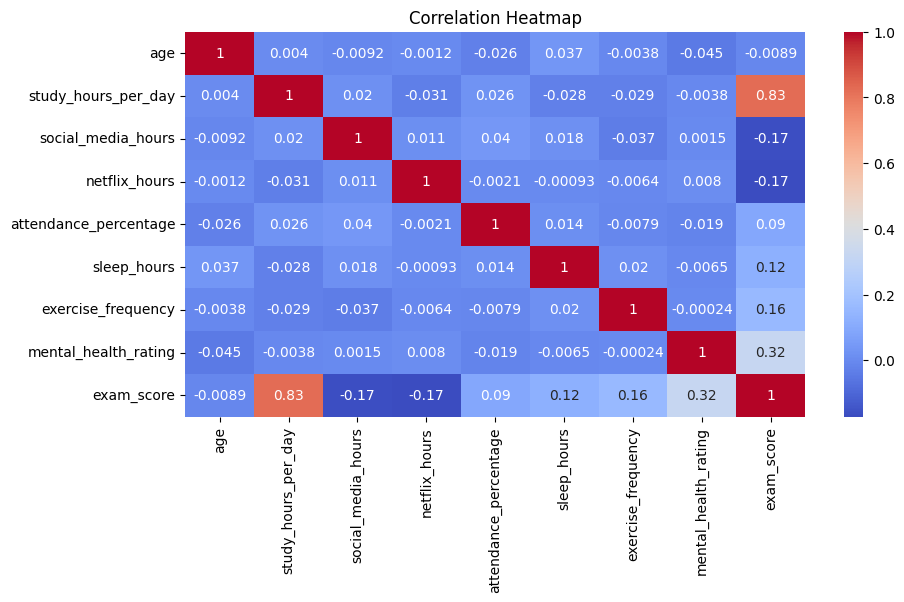

In [57]:
plt.figure(figsize=(10,5))
sbn.heatmap(habits.drop(columns=['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality',
       'extracurricular_participation']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [58]:
by_gender = habits.groupby('gender').mean(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exam_score']).reset_index()
by_gender_melt = by_gender.melt(id_vars='gender', var_name='category', value_name='value')

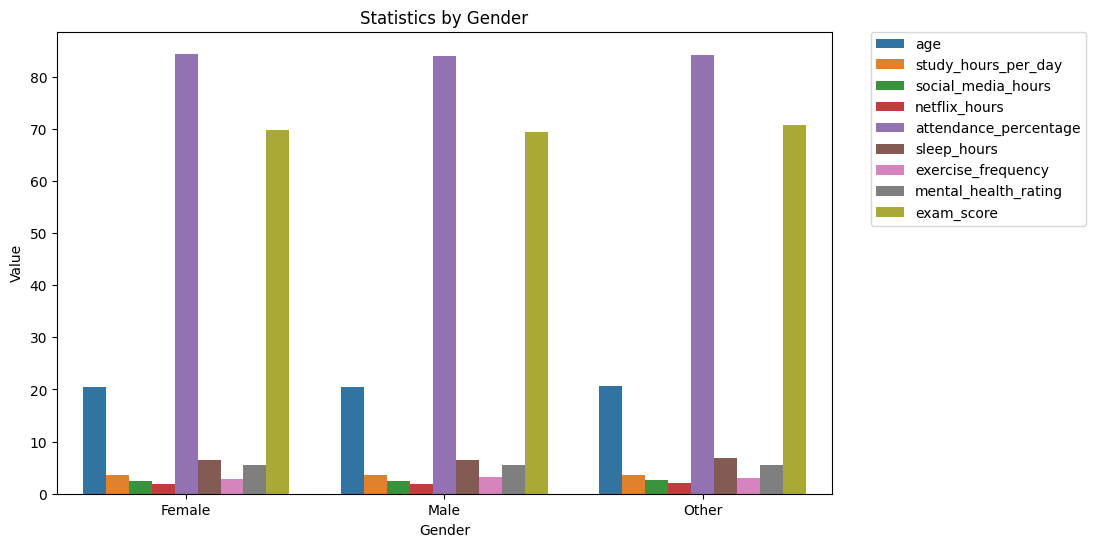

In [59]:
plt.figure(figsize=(10, 6))
sbn.barplot(x='gender', y='value', hue='category', data=by_gender_melt)
plt.title('Statistics by Gender')
plt.xlabel('Gender')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.show()

In [60]:
by_gender

,gender,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
0,Female,20.422037,3.583784,2.503950,1.797921,84.371518,6.471726,2.906445,5.453222,69.741372
1,Male,20.559748,3.510692,2.499371,1.820755,83.894549,6.438994,3.186583,5.419287,69.368344
2,Other,20.666667,3.611905,2.592857,2.057143,84.078571,6.804762,2.952381,5.476190,70.647619


 Adding a new column for Grade Category with interval of 10 marks



In [61]:
conditions = [
    (habits['exam_score'] == 100),
    (habits['exam_score'] >= 90),
    (habits['exam_score'] >= 80),
    (habits['exam_score'] >= 70),
    (habits['exam_score'] >= 60),
    (habits['exam_score'] >= 50),
    (habits['exam_score'] >= 40),
]

grades = ['A', 'B', 'C', 'D', 'E', 'E+', 'E++']
habits['grade'] = np.select(conditions, grades, default='Fail')

In [62]:
by_grade = habits.groupby('grade').mean(['study_hours_per_day',	'social_media_hours',
                                         'netflix_hours',	'part_time_job',	'attendance_percentage',	'sleep_hours',
                                         'exercise_frequency', 'mental_health_rating', 'exam_score'])
by_grade = by_grade.reset_index()
by_grade_melt = by_grade.melt(id_vars='grade', var_name='category', value_name='value')

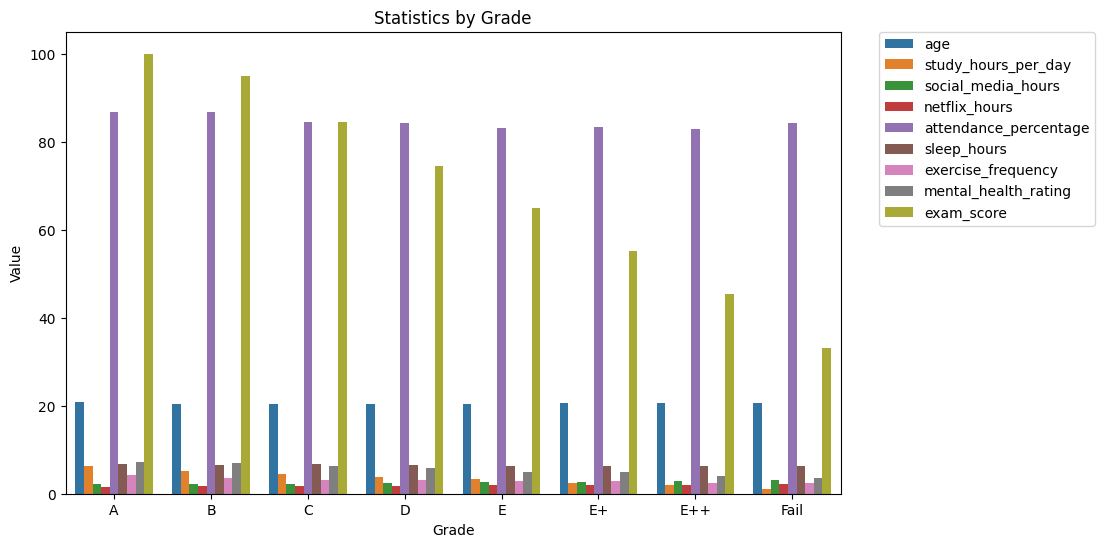

In [63]:
plt.figure(figsize=(10, 6))
sbn.barplot(x='grade', y='value', hue='category', data=by_grade_melt)
plt.title('Statistics by Grade')
plt.xlabel('Grade')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.show()

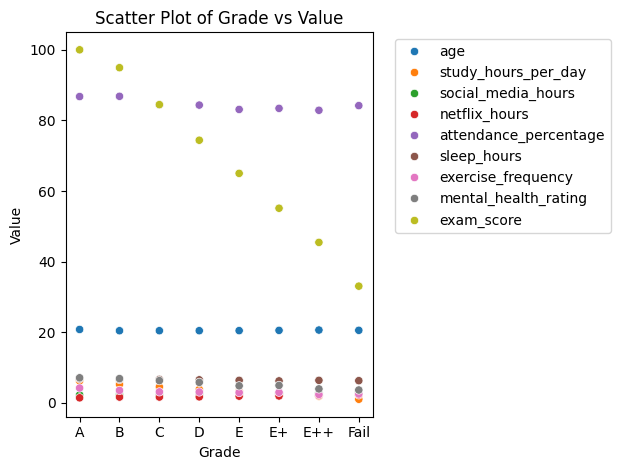

In [64]:
sbn.scatterplot(data=by_grade_melt, x='grade', y='value', hue='category')
plt.title('Scatter Plot of Grade vs Value')
plt.xlabel('Grade')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

In [65]:
parentalEducation = habits.groupby('parental_education_level').mean(['study_hours_per_day',	'social_media_hours',
                                         'netflix_hours',	'part_time_job',	'attendance_percentage',	'sleep_hours',
                                         'exercise_frequency', 'mental_health_rating', 'exam_score']).reset_index()
parentalEducation.drop('age', axis=1, inplace=True)

In [66]:
pe_hours = parentalEducation.drop(columns=['attendance_percentage', 'exam_score', 'exercise_frequency', 'mental_health_rating'])
pe_hours_melt = pe_hours.melt(id_vars='parental_education_level', var_name='category', value_name='value').reset_index()

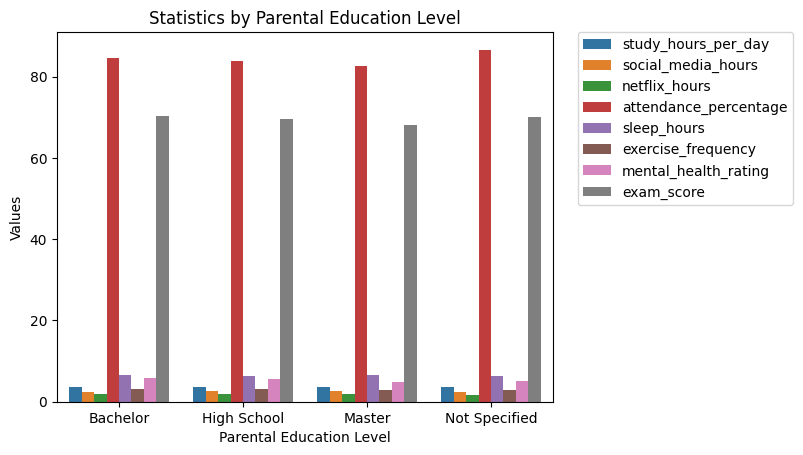

In [67]:
parentalEducation_melt = parentalEducation.melt(id_vars='parental_education_level', var_name='category', value_name='value')
sbn.barplot(x='parental_education_level', y='value', hue='category', data=parentalEducation_melt)
plt.title('Statistics by Parental Education Level')
plt.xlabel('Parental Education Level')
plt.ylabel('Values')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.show()

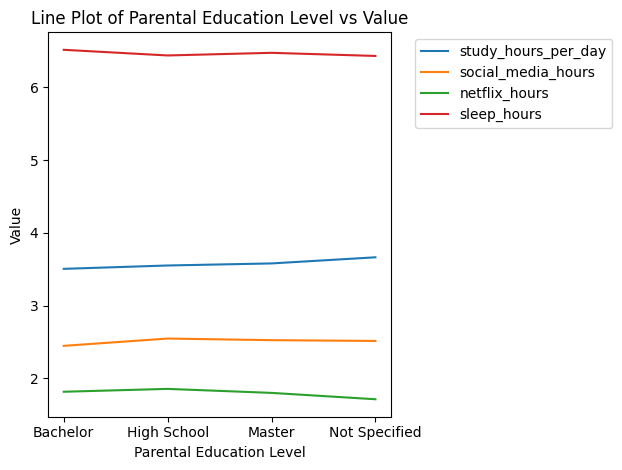

In [68]:
sbn.lineplot(data=pe_hours_melt, x='parental_education_level', y='value', hue='category')
plt.title('Line Plot of Parental Education Level vs Value')
plt.xlabel('Parental Education Level')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

# Summary for Analysis

## Initial Processing
- Replaced `NaN` values in **Parental Education** with `'Not Specified'` for ease in plotting.
- Added a new column **'Grade'** with intervals of 10 marks, assigning letter grades from **A to Fail**.
- Plotted graphs using **mean values** for visual comparisons.

## Analysis
- The dataset includes habits of students aged **17 to 24**, along with their **exam scores**. Additional features include **parental education level** and **internet quality**.
- **Minimum score**: 18, **Maximum score**: 100, **Mean score**: 69.18.
- On average, **females performed better** than males and other genders, although **Other** gender group slightly outperformed in group averages.
- Females also had **higher attendance** and **more study hours**. Other genders showed slightly higher group averages in some habits.
- **High scorers** (Grades A and B) had:
  - Most **study hours**
  - Highest **attendance percentage**
  - Lowest **social media** and **Netflix usage**

- On the **health front**, high scorers had:
  - Better **mental health ratings**
  - More **sleep hours**
  - Suggesting a link between academic performance and personal well-being.

- Regarding **Parental Education**:
  - The `'Not Specified'` group either reflects **low education** or **missing data**. No assumptions or bias were introduced during analysis.
  - Interestingly, this group showed the **best academic habits and results** — low media usage, high attendance, high exam scores, and study time.
  - The group with **'Masters' education** showed **no significant advantage**. In fact, a visible drop in **attendance**, **exercise frequency**, and **mental health rating** was observed.

- **Correlations**:
  - Highest correlation with **exam score**:  
    - **Study hours**: 0.82  
    - **Mental health rating**: 0.18  
    - **Exercise frequency**: 0.17
    - **Netflix and social media**: -0.17
  - Other features had **no significant correlation** with each other.


# Feature Selection and Feature Extraction

In [69]:
replaceLabels = {
    'Male' : 0,
    'Female' : 1,
    'Other' : 3,
    'High School' : 0,
    'Bachelor' : 1,
    'Master' : 2,
    'Not Specified' : 3,
    'Poor' : 0,
    'Average' : 1,
    'Fair' : 1,
    'Good' : 2,
    'Yes' : 0,
    'No' : 1
}

habits_labelled = habits.replace(replaceLabels)
habits_labelled.drop(columns=['student_id'], inplace=True)
habits_labelled.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,grade
0,23,1,0.0,1.2,1.1,1,85.0,8.0,1,6,2,1,8,0,56.2,E+
1,20,1,6.9,2.8,2.3,1,97.3,4.6,2,6,0,1,8,1,100.0,A
2,21,0,1.4,3.1,1.3,1,94.8,8.0,0,1,0,0,1,1,34.3,Fail
3,23,1,1.0,3.9,1.0,1,71.0,9.2,0,4,2,2,1,0,26.8,Fail
4,19,1,5.0,4.4,0.5,1,90.9,4.9,1,3,2,2,1,1,66.4,E


<Axes: >

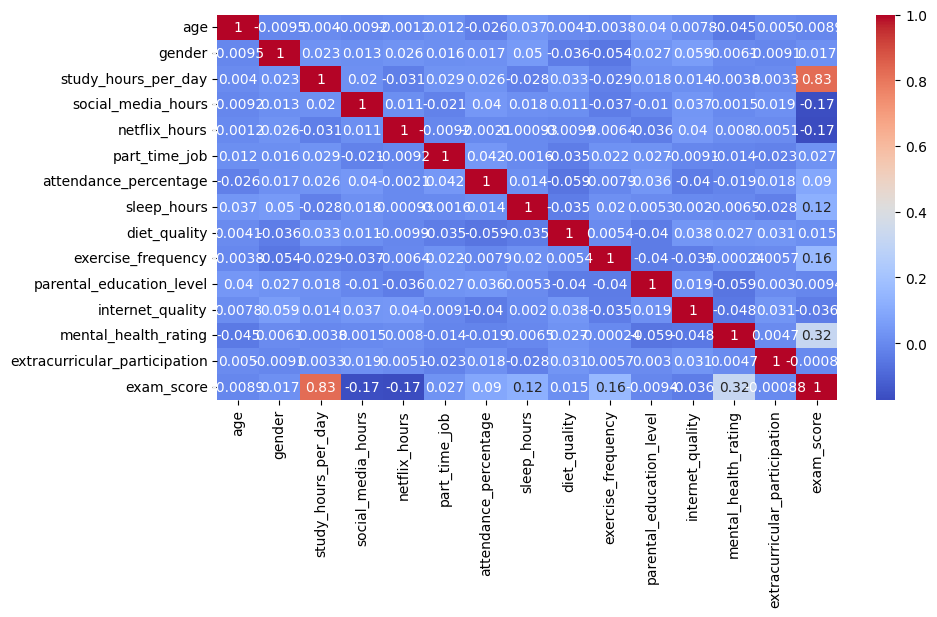

In [70]:
plt.figure(figsize=(10,5))
sbn.heatmap(habits_labelled.drop(columns='grade').corr(), annot=True, cmap='coolwarm')

**1.** Using Feature Multiplication

In [71]:
from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
ss = MinMaxScaler()
habits_labelled[cols_to_scale] = ss.fit_transform(habits_labelled[cols_to_scale])
habits_labelled.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,grade
0,23,1,0.000000,0.166667,0.203704,1,85.0,0.705882,1,1.000000,2,1,0.777778,0,56.2,E+
1,20,1,0.831325,0.388889,0.425926,1,97.3,0.205882,2,1.000000,0,1,0.777778,1,100.0,A
2,21,0,0.168675,0.430556,0.240741,1,94.8,0.705882,0,0.166667,0,0,0.000000,1,34.3,Fail
3,23,1,0.120482,0.541667,0.185185,1,71.0,0.882353,0,0.666667,2,2,0.000000,0,26.8,Fail
4,19,1,0.602410,0.611111,0.092593,1,90.9,0.250000,1,0.500000,2,2,0.000000,1,66.4,E


In [72]:
habits_labelled['study_sleep_exercise_mental'] = habits_labelled['study_hours_per_day'] * habits_labelled['sleep_hours'] * habits_labelled['exercise_frequency'] * habits_labelled['mental_health_rating']

Text(0.5, 1.0, 'Correlation Map for final features')

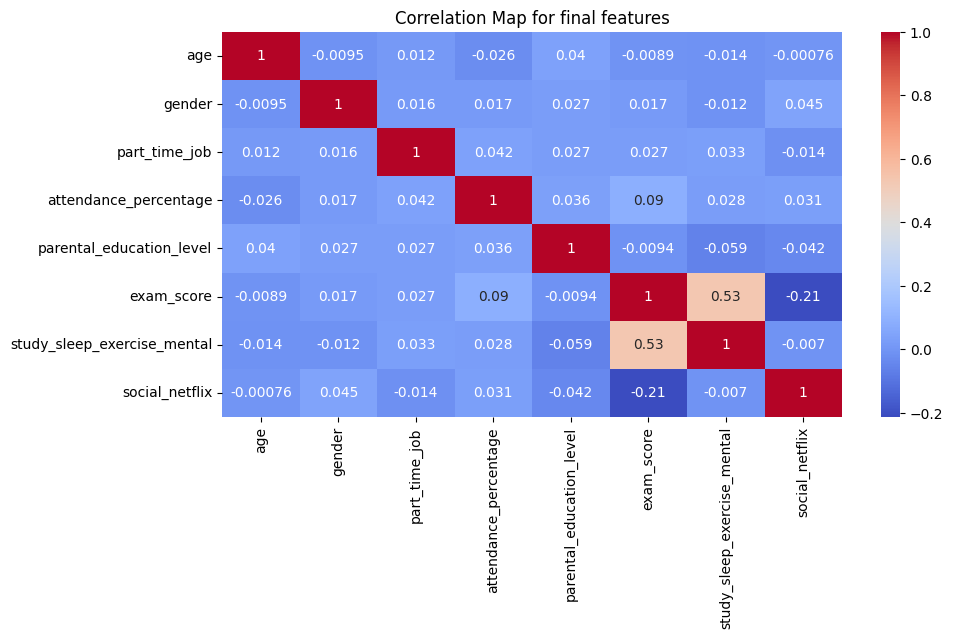

In [73]:
featureMul = habits_labelled.drop(columns=['study_hours_per_day', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'grade'])
featureMul['social_netflix'] = featureMul['social_media_hours'] * featureMul['netflix_hours']
featureMul.drop(columns=['social_media_hours', 'netflix_hours', 'diet_quality', 'extracurricular_participation', 'internet_quality'], inplace=True)
plt.figure(figsize=(10,5))
sbn.heatmap(featureMul.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Map for final features')

**2.** Using PCA for weak features

In [74]:
from sklearn.decomposition import PCA

to_apply = ['part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']
pca = PCA(n_components=2)
habits_labelled_pca = pca.fit_transform(habits_labelled[to_apply])
pcaWeak = habits_labelled
temp = pd.DataFrame(habits_labelled_pca, columns=['PC1', 'PC2'])
pcaWeak = pd.concat([pcaWeak, temp], axis=1)
pcaWeak.drop(columns=to_apply, inplace=True)
pcaWeak.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,grade,study_sleep_exercise_mental,PC1,PC2
0,23,1,0.000000,0.166667,0.203704,85.0,0.705882,1.000000,0.777778,56.2,E+,0.000000,1.047045,-0.349949
1,20,1,0.831325,0.388889,0.425926,97.3,0.205882,1.000000,0.777778,100.0,A,0.133121,-1.014226,0.323375
2,21,0,0.168675,0.430556,0.240741,94.8,0.705882,0.166667,0.000000,34.3,Fail,0.000000,-0.907520,-1.765000
3,23,1,0.120482,0.541667,0.185185,71.0,0.882353,0.666667,0.000000,26.8,Fail,0.000000,1.145202,-0.294219
4,19,1,0.602410,0.611111,0.092593,90.9,0.250000,0.500000,0.000000,66.4,E,0.000000,1.078139,0.428587


In [75]:
pcaWeak['study_sleep_exercise_mental'] = pcaWeak['study_hours_per_day'] * pcaWeak['sleep_hours'] * pcaWeak['exercise_frequency'] * pcaWeak['mental_health_rating']
pcaWeak['social_netflix'] = pcaWeak['social_media_hours'] * pcaWeak['netflix_hours']
pcaWeak.drop(columns=['study_hours_per_day', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'grade', 'social_media_hours', 'netflix_hours'], inplace=True)
pcaWeak['score'] = pcaWeak['exam_score']
pcaWeak.drop(columns='exam_score', inplace=True)

In [76]:
pcaWeak.rename(columns={'PC1': 'weak_1', 'PC2': 'weak_2'}, inplace=True)
pcaWeak.head()

,age,gender,attendance_percentage,study_sleep_exercise_mental,weak_1,weak_2,social_netflix,score
0,23,1,85.0,0.000000,1.047045,-0.349949,0.033951,56.2
1,20,1,97.3,0.133121,-1.014226,0.323375,0.165638,100.0
2,21,0,94.8,0.000000,-0.907520,-1.765000,0.103652,34.3
3,23,1,71.0,0.000000,1.145202,-0.294219,0.100309,26.8
4,19,1,90.9,0.000000,1.078139,0.428587,0.056584,66.4


<Axes: >

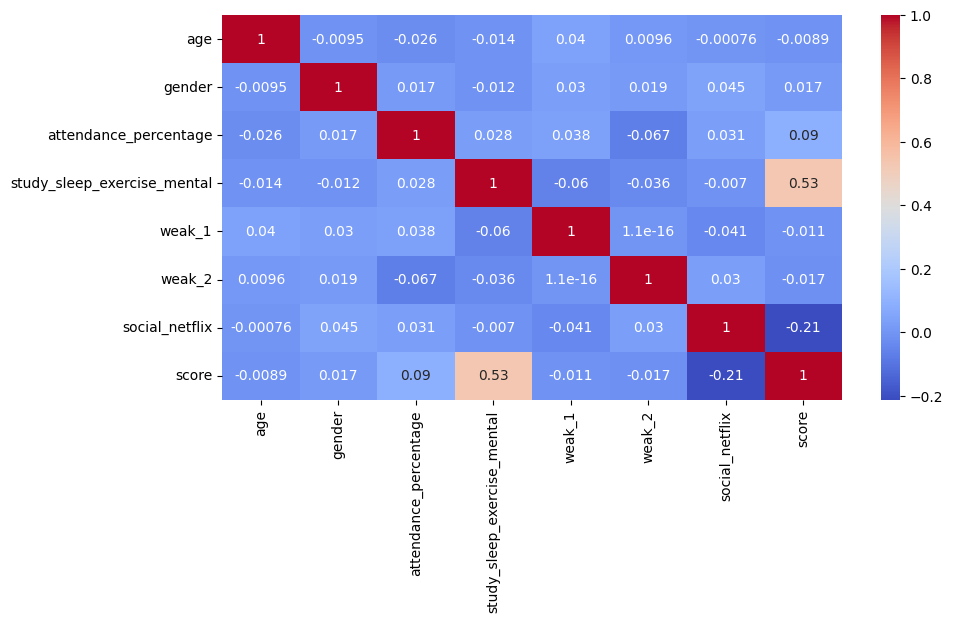

In [77]:
plt.figure(figsize=(10,5))
sbn.heatmap(pcaWeak.corr(), annot=True, cmap='coolwarm')

**3.** Using decision tree to find important feature

In [78]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

X = habits_labelled.drop(columns=['exam_score', 'grade', 'age', 'study_sleep_exercise_mental'])
y = habits_labelled['exam_score']

In [79]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
tree = DecisionTreeRegressor(max_depth=10, min_samples_split=13, min_samples_leaf=15)
tree.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=15, min_samples_split=13)

In [80]:
imp_features = pd.Series(tree.feature_importances_, index=X.columns)
print(imp_features.sort_values(ascending=False))

study_hours_per_day              0.805465
mental_health_rating             0.110169
netflix_hours                    0.022277
social_media_hours               0.018795
sleep_hours                      0.018149
exercise_frequency               0.013961
attendance_percentage            0.009945
diet_quality                     0.001239
gender                           0.000000
part_time_job                    0.000000
parental_education_level         0.000000
internet_quality                 0.000000
extracurricular_participation    0.000000
dtype: float64


In [81]:
dcrFeatures = habits_labelled.drop(columns=['diet_quality', 'gender', 'part_time_job', 'parental_education_level', 'internet_quality'
, 'extracurricular_participation', 'study_sleep_exercise_mental', 'grade'])
dcrFeatures.head(3)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
0,23,0.000000,0.166667,0.203704,85.0,0.705882,1.000000,0.777778,56.2
1,20,0.831325,0.388889,0.425926,97.3,0.205882,1.000000,0.777778,100.0
2,21,0.168675,0.430556,0.240741,94.8,0.705882,0.166667,0.000000,34.3


# Summary For Feature Extraction/Selection

## Feature Engineering Summary

- Processed categorical features into proper numerical labels.
- Used **three different methods** to gather important features:
  
  1. **Feature Multiplication**:
     - Combined highly correlated features into meaningful composite metrics:
       - `study_hours × sleep_hours × exercise_frequency × mental_health`
       - `netflix_hours × social_media_hours`
  
  2. **PCA on Weaker Features**:
     - Applied Principal Component Analysis to lower-correlation categorical features:
       - `part_time_job`, `diet_quality`, `parental_education_level`, `internet_quality`, `extracurricular_participation`
     - Generated two principal components (`weak_1`, `weak_2`)

  3. **Feature Importances via Decision Tree**:
     - Trained a `DecisionTreeRegressor` to extract importance scores.
     - Identified and ranked features based on their contribution to prediction.
     - Hyperparameters were adjusted iteratively for best results, resulting in max depth of 10, min leaf samples of 15and  min split of 13.

- The best features from these three methods will be **verified through regression model results**.


# Using Regression to predict exam scores

## The three datasets used are:
- featureMul
- pcaWeak
- dcrFeatures

In [82]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix

In [83]:
#Using featureMul
X = featureMul.drop(columns='exam_score')
y = featureMul['exam_score']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [84]:
lr = LinearRegression()
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='r2')
featureMul_model = lr.fit(x_train, y_train)
featureMul_pred = featureMul_model.predict(x_test)

In [85]:
print('Mean Squared Error: ' + str(mean_squared_error(y_test, featureMul_pred)))
print('R2 Score: ' + str(r2_score(y_test, featureMul_pred)))
print('Cross validated mean score: ' + str(cv_scores.mean()))

Mean Squared Error: 159.72215755790202
R2 Score: 0.39706496246264056
Cross validated mean score: 0.30919640639749935


In [86]:
#using pcaWeak
X = pcaWeak.drop(columns='score')
y = pcaWeak['score']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [87]:
lr = LinearRegression()
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='r2')
pcaWeak_model = lr.fit(x_train, y_train)
pcaWeak_pred = pcaWeak_model.predict(x_test)

In [88]:
print('Mean Squared Error: ' + str(mean_squared_error(y_test, pcaWeak_pred)))
print('R2 Score: ' + str(r2_score(y_test, pcaWeak_pred)))
print('Cross validated mean score: ' + str(cv_scores.mean()))

Mean Squared Error: 159.80812235774275
R2 Score: 0.39674045401239577
Cross validated mean score: 0.30812311025640576


In [89]:
#using dcrFeatures
X = dcrFeatures.drop(columns='exam_score')
y = dcrFeatures['exam_score']
y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1))
x_train, x_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=41)


In [90]:
lr = LinearRegression()
cv_scores = cross_val_score(lr, X, y_scaled, cv=5, scoring='r2')
dcrFeatures_model = lr.fit(x_train, y_train)
dcrFeatures_pred_scaled = dcrFeatures_model.predict(x_test)
dcrFeatures_pred = y_scaler.inverse_transform(dcrFeatures_pred_scaled.reshape(-1,1))

In [91]:
print('Mean Squared Error: ' + str(mean_squared_error(y_scaler.inverse_transform(y_test.reshape(-1,1)), dcrFeatures_pred)))
print('R2 Score: ' + str(r2_score(y_scaler.inverse_transform(y_test.reshape(-1,1)), dcrFeatures_pred)))
print('Cross validated mean score: ' + str(cv_scores.mean()))

Mean Squared Error: 25.606780685592568
R2 Score: 0.9033369852377451
Cross validated mean score: 0.8973346377430111


In [92]:
featureTests = pd.DataFrame(columns=['feature', 'mse', 'r2', 'mean cv'])
new_rows = [
    {'feature': 'featureMul', 'mse': 159.722, 'r2' : 0.397, 'mean cv' : 0.309},
    {'feature': 'pcaWeak', 'mse': 159.808, 'r2' : 0.396, 'mean cv' : 0.308},
    {'feature': 'dcrFeatures', 'mse': 25.606, 'r2' : 0.903, 'mean cv' : 0.897}
]

featureTests = pd.concat([featureTests, pd.DataFrame(new_rows)], ignore_index=True)
featureTests

,feature,mse,r2,mean cv
0,featureMul,159.722,0.397,0.309
1,pcaWeak,159.808,0.396,0.308
2,dcrFeatures,25.606,0.903,0.897


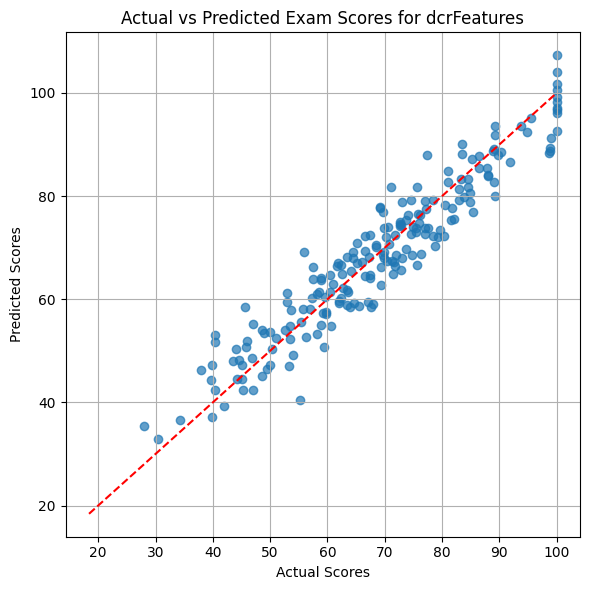

In [93]:
plt.figure(figsize=(6, 6))
plt.scatter(y_scaler.inverse_transform(y_test.reshape(-1,1)), dcrFeatures_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')  # ideal line
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Exam Scores for dcrFeatures')
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary for Regression Prediction

## 📊 Model Comparison Summary

| Method         | MSE     | R² Score | Mean CV R² |
|----------------|---------|----------|-------------|
| **Feature Multiplication** (`featureMul`) | 159.72  | 0.397    | 0.309       |
| **PCA on Weak Features** (`pcaWeak`)      | 159.81  | 0.396    | 0.308       |
| **Decision Tree Selected Features** (`dcrFeatures`) | **25.61** | **0.903**  | **0.897**     |

---

### 🔍 Insights

- **Feature Multiplication** and **PCA-transformed features** performed similarly, with high prediction error and low explanatory power (R² ~0.40).
- **Decision Tree-selected features** delivered:
  - **Lowest MSE (25.61)** – most accurate predictions.
  - **Highest R² (0.903)** – best fit to the data.
  - **Strong cross-validation score (0.897)** – excellent generalization.

---

### ✅ Conclusion

The model using **features selected from the Decision Tree Regressor** significantly outperforms the other methods and should be used as the final feature set.
